# Etapa 5 — Recomendação de compra e retorno

Este notebook traduz segmentos robustos do Airbnb para anúncios comparáveis do VivaReal e produz uma recomendação executiva.

O retorno é uma estimativa **desalavancada, antes de tributos sobre renda**, baseada em preços anunciados e ocupação hipotética. ITBI e emolumentos são separados de premissas operacionais. Financiamento, imposto de renda e estrutura societária não são modelados.


In [1]:
from pathlib import Path
import hashlib
import itertools
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 180)
plt.style.use('seaborn-v0_8-whitegrid')


def encontrar_raiz(inicio=None):
    caminho = Path(inicio or Path.cwd()).resolve()
    for candidato in (caminho, *caminho.parents):
        if (candidato / 'data').is_dir() and (candidato / 'ROADMAP.md').is_file():
            return candidato
    raise FileNotFoundError('Raiz do projeto não encontrada.')


def sha256(caminho, tamanho_bloco=1024 * 1024):
    resumo = hashlib.sha256()
    with caminho.open('rb') as arquivo:
        for bloco in iter(lambda: arquivo.read(tamanho_bloco), b''):
            resumo.update(bloco)
    return resumo.hexdigest().upper()


def converter_booleano(serie):
    if pd.api.types.is_bool_dtype(serie.dtype):
        return serie.astype('boolean')
    return serie.astype('string').str.strip().str.lower().map(
        {'true': True, 'false': False, '1': True, '0': False}
    ).astype('boolean')


RAIZ = encontrar_raiz()
DADOS = RAIZ / 'data'
METRICAS = RAIZ / 'outputs' / 'metricas'
AUDITORIA = RAIZ / 'outputs' / 'auditoria'
TESE = RAIZ / 'outputs' / 'tese'
SAIDAS = RAIZ / 'outputs' / 'recomendacao'
SAIDAS.mkdir(parents=True, exist_ok=True)

HASHES_DADOS = {
    'Details_Itapema.csv': '7A28A35811B5B01CA046D06E0AF80180E43D07AF6923FC03B76DF99AC01050C9',
    'Hosts_ids_Itapema.csv': 'B2E5AA3E0BD30A3FA63643ABC4BC3142C78BE165855BBD6C4D077D6BDE308EA9',
    'Mesh_Ids_Data_Itapema.csv': '7C9DAA0D37FE5C8FA10E6EFA53CB9E6F66E28880E165A62D3E1F9C74585ADF1E',
    'Price_AV_Itapema.csv': 'B0B5C8C07011DAF5C91F2FB9E7BA735026F0AE4542745481376140A714DD813B',
    'VivaReal_Itapema.csv': 'C720320AE6BCD34982323A2D6EEC6D5F5F18E316B3A3DAE0A37F03638E32A631',
}
hashes_antes = {p.name: sha256(p) for p in DADOS.glob('*.csv')}
assert hashes_antes == HASHES_DADOS
assert (TESE / 'veredito_tese.md').is_file(), 'Execute a Etapa 4 antes da Etapa 5.'
print(f'Saídas: {SAIDAS}')

Saídas: C:\Users\rewel\Documents\jt2026-Antonio-Rewelli-Santos\outputs\recomendacao


In [2]:
airbnb = pd.read_csv(
    METRICAS / 'metricas_por_anuncio.csv', dtype={'airbnb_listing_id': 'string'}, low_memory=False
)
vendas = pd.read_csv(AUDITORIA / 'vivareal_listings.csv', low_memory=False)
airbnb['amostra_elegivel_14_datas'] = converter_booleano(
    airbnb['amostra_elegivel_14_datas']
).fillna(False)
vendas['flag_preco_venda_invalido'] = converter_booleano(vendas['flag_preco_venda_invalido']).fillna(False)

airbnb_elegivel = airbnb.loc[
    airbnb['amostra_elegivel_14_datas'] & airbnb['listing_type'].eq('apartamento')
].copy()
vendas_validas = vendas.loc[
    vendas['listing_type'].eq('apartamento')
    & ~vendas['flag_preco_venda_invalido']
    & vendas['sale_price'].gt(0)
    & vendas['usable_area'].gt(0)
].copy()


def faixa_quartos(valor):
    valor = int(valor)
    return '4+' if valor >= 4 else str(valor)


airbnb_elegivel['quartos_faixa'] = airbnb_elegivel['number_of_bedrooms'].map(faixa_quartos)
vendas_validas['quartos_faixa'] = vendas_validas['bedrooms'].map(faixa_quartos)
vendas_validas['preco_m2_anunciado'] = vendas_validas['sale_price'] / vendas_validas['usable_area']
vendas_validas['condominio_positivo'] = vendas_validas['monthly_condo_fee'].where(
    vendas_validas['monthly_condo_fee'].gt(0)
)
vendas_validas['iptu_positivo'] = vendas_validas['yearly_iptu'].where(
    vendas_validas['yearly_iptu'].gt(0)
)

dimensoes = ['suburb_key', 'quartos_faixa']
metricas_airbnb = airbnb_elegivel.groupby(dimensoes).agg(
    anuncios_airbnb=('airbnb_listing_id', 'size'),
    diaria_p25_anunciada=('diaria_mediana_anunciada', lambda s: s.quantile(0.25)),
    diaria_mediana_anunciada=('diaria_mediana_anunciada', 'median'),
    diaria_p75_anunciada=('diaria_mediana_anunciada', lambda s: s.quantile(0.75)),
).reset_index()
metricas_vendas = vendas_validas.groupby(dimensoes).agg(
    anuncios_vivareal=('listing_id', 'size'),
    preco_p25_anunciado=('sale_price', lambda s: s.quantile(0.25)),
    preco_mediano_anunciado=('sale_price', 'median'),
    preco_p75_anunciado=('sale_price', lambda s: s.quantile(0.75)),
    area_mediana_m2=('usable_area', 'median'),
    preco_m2_mediano_anunciado=('preco_m2_anunciado', 'median'),
    condominio_mensal_mediano=('condominio_positivo', 'median'),
    anuncios_com_condominio=('condominio_positivo', 'count'),
    iptu_anual_mediano=('iptu_positivo', 'median'),
    anuncios_com_iptu=('iptu_positivo', 'count'),
).reset_index()

candidatos = metricas_airbnb.merge(metricas_vendas, on=dimensoes, validate='one_to_one')
candidatos = candidatos.loc[
    candidatos['anuncios_airbnb'].ge(20)
    & candidatos['anuncios_vivareal'].ge(20)
    & candidatos['quartos_faixa'].isin(['1', '2', '3', '4+'])
].copy()
candidatos['segmento'] = candidatos['suburb_key'] + '_' + candidatos['quartos_faixa'].str.replace('+', 'mais', regex=False) + 'q'
rotulos_bairros = {'centro': 'Centro', 'meiapraia': 'Meia Praia', 'morretes': 'Morretes'}
rotulos_quartos = {'1': '1 quarto', '2': '2 quartos', '3': '3 quartos', '4+': '4+ quartos'}
candidatos['rotulo'] = candidatos['suburb_key'].map(rotulos_bairros) + ' | ' + candidatos['quartos_faixa'].map(rotulos_quartos)
candidatos['cobertura_condominio_percentual'] = candidatos['anuncios_com_condominio'] / candidatos['anuncios_vivareal'] * 100
candidatos['cobertura_iptu_percentual'] = candidatos['anuncios_com_iptu'] / candidatos['anuncios_vivareal'] * 100
assert len(candidatos) > 1
display(candidatos[['rotulo', 'anuncios_airbnb', 'anuncios_vivareal', 'diaria_mediana_anunciada', 'preco_mediano_anunciado']])

,rotulo,anuncios_airbnb,anuncios_vivareal,diaria_mediana_anunciada,preco_mediano_anunciado
5,Centro | 1 quarto,78,22,445.0,890000.0
6,Centro | 2 quartos,64,89,568.5,1150000.0
7,Centro | 3 quartos,43,437,750.0,2100000.0
11,Meia Praia | 1 quarto,20,58,441.0,877500.0
12,Meia Praia | 2 quartos,183,243,450.0,1080000.0
13,Meia Praia | 3 quartos,312,1697,650.0,1885000.0
14,Meia Praia | 4+ quartos,62,1403,1125.0,3700000.0
16,Morretes | 2 quartos,47,1037,458.0,790000.0


In [3]:
# Fontes legais vigentes consultadas em 26/08/2026.
URL_ITBI = 'https://site.itapema.sc.leg.br/elegis2/detalhe-proposicao/cod_proposicao/24075'
URL_TJSC = 'https://www.tjsc.jus.br/documents/d/corregedoria-geral-da-justica/circularcgj643-2025-pdf'

ALIQUOTA_ITBI = 0.015  # alíquota geral; PL 776/2025 foi retirado e arquivado em 03/03/2026
META_RETORNO = 0.08    # regra de decisão assumida, não benchmark observado


def custo_cartorio_2026(preco):
    # Estimativa de escritura + registro para valores acima de R$ 226.100,05.
    # Bases: Tabela I, item 2.21/2.22, e Tabela III, item 2.2.21/2.2.22 do TJSC.
    limite = 226_100.05
    adicionais = max(0, math.ceil((preco - limite) / 50_000))
    proporcao_frj = 0.2273
    escritura_base = 2_142.42 + 486.97
    registro_base = 2_091.41 + 475.37
    adicional_por_ato = 50 * (1 + proporcao_frj)
    return escritura_base + registro_base + 2 * adicionais * adicional_por_ato


parametros_retorno = pd.DataFrame([
    {'parametro': 'ocupacao_conservadora', 'valor': 0.40, 'unidade': 'proporcao', 'natureza': 'hipotese_sensibilidade', 'fonte': 'Etapa 2'},
    {'parametro': 'ocupacao_base', 'valor': 0.55, 'unidade': 'proporcao', 'natureza': 'hipotese_sensibilidade', 'fonte': 'Etapa 2'},
    {'parametro': 'ocupacao_otimista', 'valor': 0.70, 'unidade': 'proporcao', 'natureza': 'hipotese_sensibilidade', 'fonte': 'Etapa 2'},
    {'parametro': 'custos_variaveis_baixo', 'valor': 0.20, 'unidade': 'proporcao_receita_bruta', 'natureza': 'hipotese_sensibilidade', 'fonte': 'premissa de modelagem; não é média de mercado'},
    {'parametro': 'custos_variaveis_base', 'valor': 0.30, 'unidade': 'proporcao_receita_bruta', 'natureza': 'hipotese_sensibilidade', 'fonte': 'premissa de modelagem; não é média de mercado'},
    {'parametro': 'custos_variaveis_alto', 'valor': 0.40, 'unidade': 'proporcao_receita_bruta', 'natureza': 'hipotese_sensibilidade', 'fonte': 'premissa de modelagem; não é média de mercado'},
    {'parametro': 'preparacao_baixa', 'valor': 0.03, 'unidade': 'proporcao_preco_compra', 'natureza': 'hipotese_sensibilidade', 'fonte': 'mobília/reforma combinadas; não observado'},
    {'parametro': 'preparacao_base', 'valor': 0.05, 'unidade': 'proporcao_preco_compra', 'natureza': 'hipotese_sensibilidade', 'fonte': 'mobília/reforma combinadas; não observado'},
    {'parametro': 'preparacao_alta', 'valor': 0.08, 'unidade': 'proporcao_preco_compra', 'natureza': 'hipotese_sensibilidade', 'fonte': 'mobília/reforma combinadas; não observado'},
    {'parametro': 'itbi_geral_2026', 'valor': ALIQUOTA_ITBI, 'unidade': 'proporcao_base_calculo', 'natureza': 'fonte_externa_vigente', 'fonte': URL_ITBI},
    {'parametro': 'meta_retorno_decisao', 'valor': META_RETORNO, 'unidade': 'proporcao_ano', 'natureza': 'regra_decisao_assumida', 'fonte': 'premissa explícita do case'},
    {'parametro': 'emolumentos_2026', 'valor': np.nan, 'unidade': 'R$ por faixa', 'natureza': 'estimativa_tabela_oficial', 'fonte': URL_TJSC},
])


def calcular_retorno(linha, diaria, preco, ocupacao, custo_variavel, preparacao):
    condominio = linha.condominio_mensal_mediano if pd.notna(linha.condominio_mensal_mediano) else 0
    iptu = linha.iptu_anual_mediano if pd.notna(linha.iptu_anual_mediano) else 0
    receita_bruta = diaria * 365 * ocupacao
    custos_variaveis = receita_bruta * custo_variavel
    custos_fixos = condominio * 12 + iptu
    potencial_liquido = receita_bruta - custos_variaveis - custos_fixos
    itbi = preco * ALIQUOTA_ITBI
    cartorio = custo_cartorio_2026(preco)
    custo_preparacao = preco * preparacao
    investimento = preco + itbi + cartorio + custo_preparacao
    retorno = potencial_liquido / investimento if investimento > 0 else np.nan
    payback = investimento / potencial_liquido if potencial_liquido > 0 else np.nan
    ocupacao_equilibrio = custos_fixos / (diaria * 365 * (1 - custo_variavel)) if diaria > 0 else np.nan
    return {
        'receita_bruta_anual': receita_bruta,
        'custos_variaveis_anuais': custos_variaveis,
        'custos_fixos_anuais': custos_fixos,
        'potencial_liquido_anual': potencial_liquido,
        'itbi_estimado': itbi,
        'cartorio_estimado': cartorio,
        'preparacao_estimada': custo_preparacao,
        'investimento_total_estimado': investimento,
        'retorno_liquido_estimado_percentual': retorno * 100,
        'payback_estimado_anos': payback,
        'ocupacao_equilibrio_percentual': ocupacao_equilibrio * 100,
    }


configuracoes_nomeadas = {
    'conservador': ('p25', 'p75', 0.40, 0.40, 0.08),
    'base': ('mediana', 'mediana', 0.55, 0.30, 0.05),
    'otimista': ('p75', 'p25', 0.70, 0.20, 0.03),
}
colunas_diaria = {'p25': 'diaria_p25_anunciada', 'mediana': 'diaria_mediana_anunciada', 'p75': 'diaria_p75_anunciada'}
colunas_preco = {'p25': 'preco_p25_anunciado', 'mediana': 'preco_mediano_anunciado', 'p75': 'preco_p75_anunciado'}

linhas_cenarios = []
for linha in candidatos.itertuples(index=False):
    for cenario, (metrica_d, metrica_p, ocupacao, custo_var, preparacao) in configuracoes_nomeadas.items():
        diaria = getattr(linha, colunas_diaria[metrica_d])
        preco = getattr(linha, colunas_preco[metrica_p])
        calculo = calcular_retorno(linha, diaria, preco, ocupacao, custo_var, preparacao)
        linhas_cenarios.append({
            'segmento': linha.segmento, 'rotulo': linha.rotulo, 'cenario': cenario,
            'anuncios_airbnb': linha.anuncios_airbnb, 'anuncios_vivareal': linha.anuncios_vivareal,
            'metrica_diaria': metrica_d, 'diaria_usada': diaria,
            'metrica_preco': metrica_p, 'preco_compra_usado': preco,
            'ocupacao_assumida': ocupacao, 'custo_variavel_assumido': custo_var,
            'preparacao_assumida': preparacao, **calculo,
        })
cenarios_retorno = pd.DataFrame(linhas_cenarios)

linhas_sensibilidade = []
for linha in candidatos.itertuples(index=False):
    for metrica_d, metrica_p, ocupacao, custo_var, preparacao in itertools.product(
        ['p25', 'mediana', 'p75'], ['p25', 'mediana', 'p75'],
        [0.40, 0.55, 0.70], [0.20, 0.30, 0.40], [0.03, 0.05, 0.08],
    ):
        diaria = getattr(linha, colunas_diaria[metrica_d])
        preco = getattr(linha, colunas_preco[metrica_p])
        calculo = calcular_retorno(linha, diaria, preco, ocupacao, custo_var, preparacao)
        linhas_sensibilidade.append({
            'segmento': linha.segmento, 'rotulo': linha.rotulo,
            'metrica_diaria': metrica_d, 'metrica_preco': metrica_p,
            'ocupacao_assumida': ocupacao, 'custo_variavel_assumido': custo_var,
            'preparacao_assumida': preparacao, 'diaria_usada': diaria,
            'preco_compra_usado': preco, **calculo,
        })
sensibilidade_retorno = pd.DataFrame(linhas_sensibilidade)
display(cenarios_retorno.loc[cenarios_retorno['cenario'].eq('base')].sort_values('retorno_liquido_estimado_percentual', ascending=False))

,segmento,rotulo,cenario,anuncios_airbnb,anuncios_vivareal,metrica_diaria,diaria_usada,metrica_preco,preco_compra_usado,ocupacao_assumida,custo_variavel_assumido,preparacao_assumida,receita_bruta_anual,custos_variaveis_anuais,custos_fixos_anuais,potencial_liquido_anual,itbi_estimado,cartorio_estimado,preparacao_estimada,investimento_total_estimado,retorno_liquido_estimado_percentual,payback_estimado_anos,ocupacao_equilibrio_percentual
22,morretes_2q,Morretes | 2 quartos,base,47,1037,mediana,458.0,mediana,790000.0,0.55,0.3,0.05,91943.500,27583.0500,4900.0,59460.4500,11850.0,6668.93,39500.0,848018.93,7.011689,14.261899,4.187354
4,centro_2q,Centro | 2 quartos,base,64,89,mediana,568.5,mediana,1150000.0,0.55,0.3,0.05,114126.375,34237.9125,7000.0,72888.4625,17250.0,7528.04,57500.0,1232278.04,5.914936,16.906352,4.819219
1,centro_1q,Centro | 1 quarto,base,78,22,mediana,445.0,mediana,890000.0,0.55,0.3,0.05,89333.750,26800.1250,7000.0,55533.6250,13350.0,6914.39,44500.0,954764.39,5.816474,17.192546,6.156688
10,meiapraia_1q,Meia Praia | 1 quarto,base,20,58,mediana,441.0,mediana,877500.0,0.55,0.3,0.05,88530.750,26559.2250,9730.0,52241.5250,13162.5,6914.39,43875.0,941451.89,5.549038,18.021141,8.635418
13,meiapraia_2q,Meia Praia | 2 quartos,base,183,243,mediana,450.0,mediana,1080000.0,0.55,0.3,0.05,90337.500,27101.2500,6980.0,56256.2500,16200.0,7405.31,54000.0,1157605.31,4.859709,20.577364,6.070885
7,centro_3q,Centro | 3 quartos,base,43,437,mediana,750.0,mediana,2100000.0,0.55,0.3,0.05,150562.500,45168.7500,8704.0,96689.7500,31500.0,9859.91,105000.0,2246359.91,4.304286,23.232658,4.542205
16,meiapraia_3q,Meia Praia | 3 quartos,base,312,1697,mediana,650.0,mediana,1885000.0,0.55,0.3,0.05,130487.500,39146.2500,8700.0,82641.2500,28275.0,9368.99,94250.0,2016893.99,4.097451,24.405415,5.238597
19,meiapraia_4maisq,Meia Praia | 4+ quartos,base,62,1403,mediana,1125.0,mediana,3700000.0,0.55,0.3,0.05,225843.750,67753.1250,14400.0,143690.6250,55500.0,13787.27,185000.0,3954287.27,3.633793,27.519452,5.009785


In [4]:
base_cenarios = cenarios_retorno.loc[cenarios_retorno['cenario'].eq('base')].copy()
conservador_cenarios = cenarios_retorno.loc[
    cenarios_retorno['cenario'].eq('conservador'), ['segmento', 'retorno_liquido_estimado_percentual']
].rename(columns={'retorno_liquido_estimado_percentual': 'retorno_conservador_percentual'})
otimista_cenarios = cenarios_retorno.loc[
    cenarios_retorno['cenario'].eq('otimista'), ['segmento', 'retorno_liquido_estimado_percentual']
].rename(columns={'retorno_liquido_estimado_percentual': 'retorno_otimista_percentual'})

candidatos_compra = candidatos.merge(base_cenarios.drop(columns=['rotulo', 'anuncios_airbnb', 'anuncios_vivareal']), on='segmento')
candidatos_compra = candidatos_compra.merge(conservador_cenarios, on='segmento').merge(otimista_cenarios, on='segmento')
candidatos_compra['ranking_retorno_base'] = candidatos_compra['retorno_liquido_estimado_percentual'].rank(
    method='min', ascending=False
).astype('Int64')


def preco_maximo_para_meta(linha, meta=META_RETORNO):
    diaria = linha.diaria_mediana_anunciada
    receita = diaria * 365 * 0.55
    condominio = linha.condominio_mensal_mediano if pd.notna(linha.condominio_mensal_mediano) else 0
    iptu = linha.iptu_anual_mediano if pd.notna(linha.iptu_anual_mediano) else 0
    liquido = receita * (1 - 0.30) - condominio * 12 - iptu
    inferior, superior = 1.0, max(float(linha.preco_p75_anunciado) * 2, 1_000_000)
    for _ in range(80):
        meio = (inferior + superior) / 2
        investimento = meio * (1 + ALIQUOTA_ITBI + 0.05) + custo_cartorio_2026(meio)
        if liquido / investimento >= meta:
            inferior = meio
        else:
            superior = meio
    return inferior


candidatos_compra['preco_maximo_meta_8_percentual'] = candidatos_compra.apply(preco_maximo_para_meta, axis=1)
candidatos_compra['desconto_necessario_mediana_percentual'] = (
    1 - candidatos_compra['preco_maximo_meta_8_percentual'] / candidatos_compra['preco_mediano_anunciado']
) * 100

elegiveis_principal = candidatos_compra.loc[
    candidatos_compra['retorno_conservador_percentual'].gt(0)
].sort_values('retorno_liquido_estimado_percentual', ascending=False)
principal = elegiveis_principal.iloc[0]

# Alternativa exige amostra Airbnb acima do mínimo estrito e estratégia diferente da principal.
alternativas = candidatos_compra.loc[
    candidatos_compra['segmento'].ne(principal['segmento'])
    & candidatos_compra['anuncios_airbnb'].ge(30)
    & candidatos_compra['anuncios_vivareal'].ge(20)
].sort_values('retorno_liquido_estimado_percentual', ascending=False)
alternativa = alternativas.iloc[0] if len(alternativas) else None
candidatos_compra['papel_recomendacao'] = 'nao_selecionado'
candidatos_compra.loc[candidatos_compra['segmento'].eq(principal['segmento']), 'papel_recomendacao'] = 'principal'
def formatar_brl(valor):
    return f"R$ {valor:,.0f}".replace(',', '.')


if alternativa is not None:
    candidatos_compra.loc[candidatos_compra['segmento'].eq(alternativa['segmento']), 'papel_recomendacao'] = 'alternativa'

veredito_tese_texto = (TESE / 'veredito_tese.md').read_text(encoding='utf-8')
linha_veredito = next(l for l in veredito_tese_texto.splitlines() if l.startswith('## Veredito:'))
veredito_tese = linha_veredito.replace('## Veredito:', '').replace('*', '').strip().lower()
display(candidatos_compra.sort_values('ranking_retorno_base')[['rotulo', 'papel_recomendacao', 'retorno_liquido_estimado_percentual', 'retorno_conservador_percentual', 'retorno_otimista_percentual', 'preco_maximo_meta_8_percentual']])

,rotulo,papel_recomendacao,retorno_liquido_estimado_percentual,retorno_conservador_percentual,retorno_otimista_percentual,preco_maximo_meta_8_percentual
7,Morretes | 2 quartos,principal,7.011689,2.655041,14.496457,6.918612e+05
1,Centro | 2 quartos,alternativa,5.914936,1.489776,14.755379,8.491212e+05
0,Centro | 1 quarto,nao_selecionado,5.816474,2.403079,14.546780,6.458869e+05
3,Meia Praia | 1 quarto,nao_selecionado,5.549038,2.078024,12.189184,6.073625e+05
4,Meia Praia | 2 quartos,nao_selecionado,4.859709,1.759588,11.718256,6.543684e+05
2,Centro | 3 quartos,nao_selecionado,4.304286,1.203009,8.980325,1.127788e+06
5,Meia Praia | 3 quartos,nao_selecionado,4.097451,1.330672,9.581677,9.633601e+05
6,Meia Praia | 4+ quartos,nao_selecionado,3.633793,0.967868,11.409913,1.678173e+06


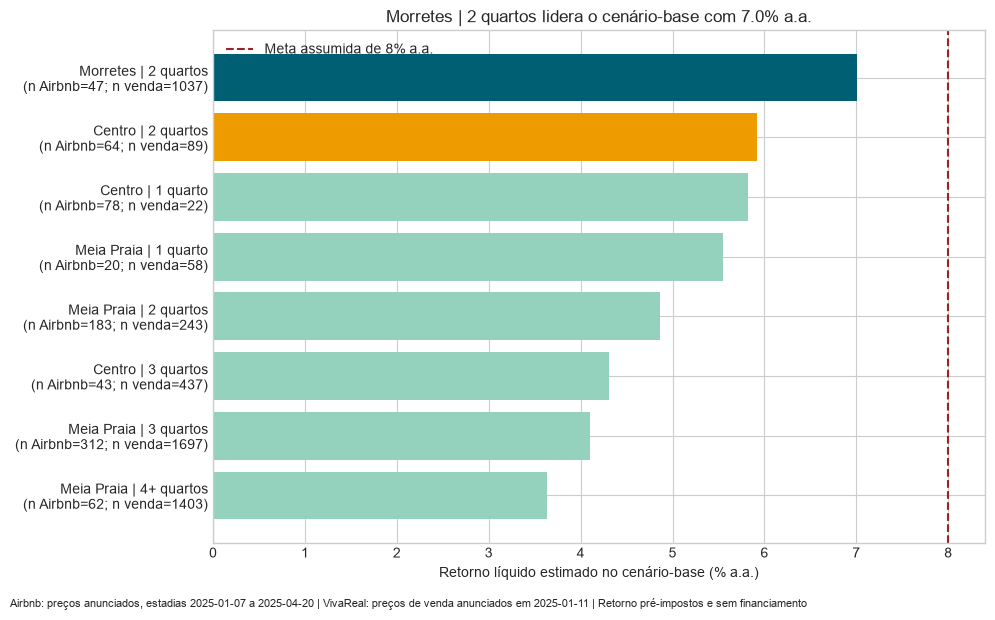

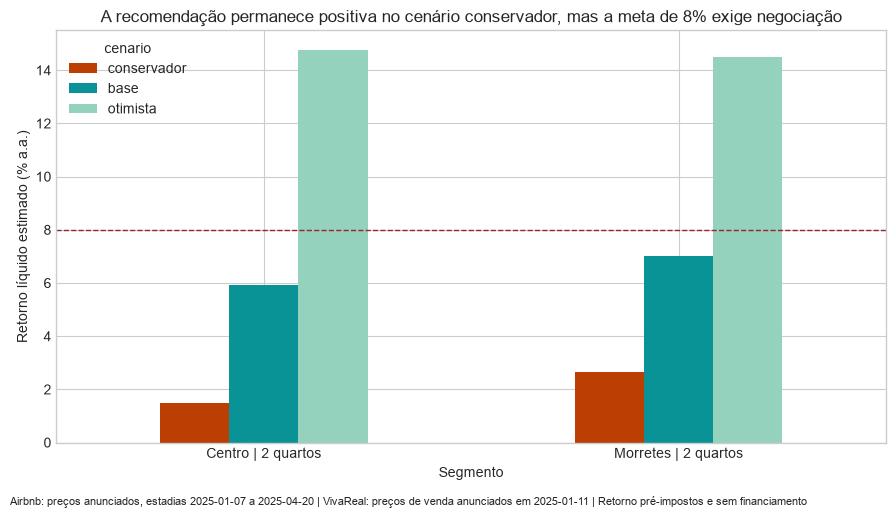

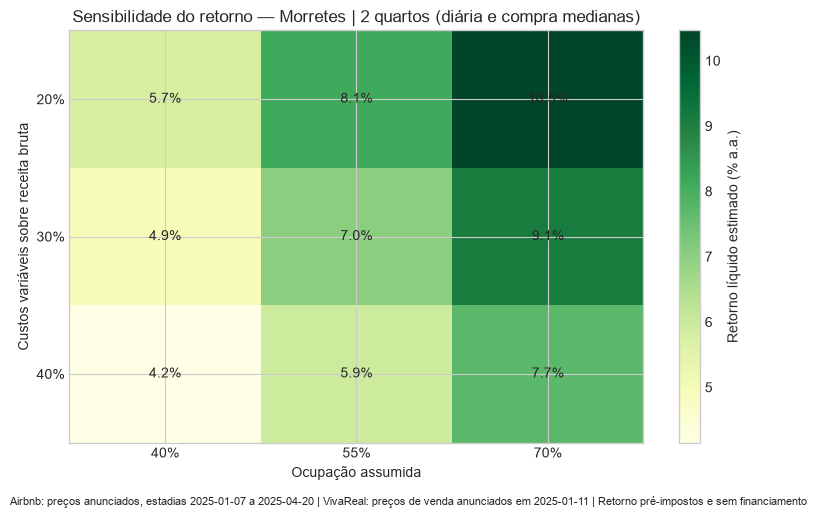

In [5]:
def caminho_saida(nome):
    destino = (SAIDAS / nome).resolve()
    assert destino.parent == SAIDAS.resolve()
    return destino


def salvar_figura(nome):
    plt.tight_layout()
    plt.savefig(caminho_saida(nome), dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()


rodape = (
    'Airbnb: preços anunciados, estadias 2025-01-07 a 2025-04-20 | '
    'VivaReal: preços de venda anunciados em 2025-01-11 | Retorno pré-impostos e sem financiamento'
)

plot_c = candidatos_compra.sort_values('retorno_liquido_estimado_percentual')
cores = plot_c['papel_recomendacao'].map(
    {'principal': '#005f73', 'alternativa': '#ee9b00', 'nao_selecionado': '#94d2bd'}
)
fig, ax = plt.subplots(figsize=(10, 6))
rotulos = [f"{r.rotulo}\n(n Airbnb={r.anuncios_airbnb}; n venda={r.anuncios_vivareal})" for r in plot_c.itertuples()]
ax.barh(rotulos, plot_c['retorno_liquido_estimado_percentual'], color=cores)
ax.axvline(META_RETORNO * 100, color='#9b2226', linestyle='--', label='Meta assumida de 8% a.a.')
ax.set_xlabel('Retorno líquido estimado no cenário-base (% a.a.)')
ax.set_title(
    f"{principal['rotulo']} lidera o cenário-base com {principal['retorno_liquido_estimado_percentual']:.1f}% a.a."
)
ax.legend()
fig.text(0.01, -0.02, rodape, fontsize=8)
salvar_figura('01_retorno_candidatos.png')

selecionados = [principal['segmento']] + ([alternativa['segmento']] if alternativa is not None else [])
plot_s = cenarios_retorno.loc[cenarios_retorno['segmento'].isin(selecionados)].copy()
pivot = plot_s.pivot(index='rotulo', columns='cenario', values='retorno_liquido_estimado_percentual')
pivot = pivot[['conservador', 'base', 'otimista']]
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind='bar', ax=ax, color=['#bb3e03', '#0a9396', '#94d2bd'])
ax.axhline(META_RETORNO * 100, color='#9b2226', linestyle='--', linewidth=1)
ax.set_ylabel('Retorno líquido estimado (% a.a.)')
ax.set_xlabel('Segmento')
ax.set_title('A recomendação permanece positiva no cenário conservador, mas a meta de 8% exige negociação')
ax.tick_params(axis='x', rotation=0)
fig.text(0.01, -0.02, rodape, fontsize=8)
salvar_figura('02_cenarios_recomendados.png')

heat = sensibilidade_retorno.loc[
    sensibilidade_retorno['segmento'].eq(principal['segmento'])
    & sensibilidade_retorno['metrica_diaria'].eq('mediana')
    & sensibilidade_retorno['metrica_preco'].eq('mediana')
    & sensibilidade_retorno['preparacao_assumida'].eq(0.05)
].pivot(index='custo_variavel_assumido', columns='ocupacao_assumida', values='retorno_liquido_estimado_percentual')
fig, ax = plt.subplots(figsize=(8, 5))
imagem = ax.imshow(heat.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(heat.columns)), [f'{x:.0%}' for x in heat.columns])
ax.set_yticks(range(len(heat.index)), [f'{x:.0%}' for x in heat.index])
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        ax.text(j, i, f'{heat.iloc[i, j]:.1f}%', ha='center', va='center')
ax.set_xlabel('Ocupação assumida')
ax.set_ylabel('Custos variáveis sobre receita bruta')
ax.set_title(f"Sensibilidade do retorno — {principal['rotulo']} (diária e compra medianas)")
fig.colorbar(imagem, ax=ax, label='Retorno líquido estimado (% a.a.)')
fig.text(0.01, -0.02, rodape, fontsize=8)
salvar_figura('03_sensibilidade_retorno.png')

In [6]:
parametros_retorno.to_csv(caminho_saida('parametros_retorno.csv'), index=False, encoding='utf-8')
candidatos_compra.to_csv(caminho_saida('candidatos_compra.csv'), index=False, encoding='utf-8')
cenarios_retorno.to_csv(caminho_saida('cenarios_retorno.csv'), index=False, encoding='utf-8')
sensibilidade_retorno.to_csv(caminho_saida('sensibilidade_retorno.csv'), index=False, encoding='utf-8')

texto_alternativa = ''
if alternativa is not None:
    texto_alternativa = f'''## Alternativa

**{alternativa['rotulo']}**, com retorno líquido estimado de {alternativa['retorno_liquido_estimado_percentual']:.2f}% a.a. no cenário-base (conservador {alternativa['retorno_conservador_percentual']:.2f}%; otimista {alternativa['retorno_otimista_percentual']:.2f}%). Sua amostra é de {int(alternativa['anuncios_airbnb'])} anúncios Airbnb e {int(alternativa['anuncios_vivareal'])} anúncios de venda.
'''

recomendacao = f'''# Recomendação executiva de investimento

## Decisão

**Priorizar {principal['rotulo']}**, mas negociar. O segmento lidera os candidatos robustos no cenário-base, com retorno líquido estimado de **{principal['retorno_liquido_estimado_percentual']:.2f}% a.a.** e payback de **{principal['payback_estimado_anos']:.1f} anos**.

- Diária mediana anunciada: {formatar_brl(principal['diaria_mediana_anunciada'])}/noite.
- Preço de venda mediano anunciado: {formatar_brl(principal['preco_mediano_anunciado'])}.
- Faixa P25–P75 de venda: {formatar_brl(principal['preco_p25_anunciado'])} a {formatar_brl(principal['preco_p75_anunciado'])}.
- Amostra: {int(principal['anuncios_airbnb'])} anúncios Airbnb e {int(principal['anuncios_vivareal'])} anúncios VivaReal.
- Cenário conservador: {principal['retorno_conservador_percentual']:.2f}% a.a.; cenário otimista: {principal['retorno_otimista_percentual']:.2f}% a.a.
- Ocupação de equilíbrio **operacional** no cenário-base: {principal['ocupacao_equilibrio_percentual']:.1f}%.
  Ela cobre condomínio, IPTU e custos variáveis; não remunera nem recupera o capital investido.

## Condição de compra

A meta de 8% a.a. é uma **regra de decisão assumida**, não um benchmark observado. Para alcançá-la com diária mediana, ocupação de 55%, custos variáveis de 30% e preparação de 5%, o preço máximo estimado é **{formatar_brl(principal['preco_maximo_meta_8_percentual'])}**. Isso representa desconto de **{principal['desconto_necessario_mediana_percentual']:.1f}%** sobre a mediana anunciada.

Se o vendedor não aceitar preço próximo desse limite, a decisão recomendada é **não comprar ainda** ou reavaliar a alternativa.

{texto_alternativa}

## Posição sobre a tese

O veredito herdado da Etapa 4 é **{veredito_tese}**. A recomendação principal resulta do retorno líquido comparado, não da hipótese inicial. Studios no Centro continuam sem amostra residencial comparável; qualquer conclusão sobre eles é inconclusiva.

## Fórmulas e premissas do cenário-base

```text
receita_bruta = diária_mediana × 365 × 55%
custos_variáveis = receita_bruta × 30%
custos_fixos = condomínio_mediano_positivo × 12 + IPTU_anual_mediano_positivo
potencial_líquido = receita_bruta - custos_variáveis - custos_fixos
investimento_total = preço_mediano + ITBI_1,5% + cartório_estimado_2026 + preparação_5%
retorno_líquido = potencial_líquido / investimento_total
payback = investimento_total / potencial_líquido
```

ITBI usa alíquota geral de 1,5% em 2026; o PL 776/2025 que propunha alteração foi retirado e arquivado em 03/03/2026: {URL_ITBI}

Cartório é estimado pelas faixas de escritura e registro da tabela 2026 do TJSC: {URL_TJSC}

Custos variáveis de 20%/30%/40% e preparação de 3%/5%/8% são hipóteses de sensibilidade, não médias observadas. Condomínio e IPTU usam apenas valores positivos e informam cobertura.

## Custos omitidos

- financiamento, juros e seguros vinculados ao crédito;
- imposto de renda e estrutura societária;
- valorização ou depreciação do imóvel;
- custos extraordinários de condomínio;
- vacância entre estadias além da ocupação assumida;
- eventual diferença entre base fiscal do ITBI e preço anunciado;
- comissão/negociação e custos jurídicos específicos.

## Riscos

- período Airbnb curto e sem ciclo anual completo;
- ausência de ocupação, reservas e receita realizadas;
- cobertura de preços Airbnb de 21,6% e possível seleção não aleatória;
- preço de venda anunciado pode diferir da transação;
- condomínio e IPTU têm cobertura parcial e podem estar desatualizados;
- sazonalidade, vacância, regulação de short stay, liquidez e qualidade do anúncio;
- correspondência agregada entre portais, sem identificar o mesmo imóvel.

## O que faria a decisão mudar

- preço negociado acima do limite compatível com a meta escolhida;
- ocupação estrutural abaixo do equilíbrio;
- custos variáveis acima do cenário alto;
- condomínio/IPTU reais materialmente superiores às medianas;
- due diligence revelar restrição condominial ou regulatória ao short stay;
- dados anuais de receita mostrarem diária ou sazonalidade inferiores às proxies.
'''
caminho_saida('recomendacao_executiva.md').write_text(recomendacao, encoding='utf-8')

hashes_depois = {p.name: sha256(p) for p in DADOS.glob('*.csv')}
assert hashes_depois == hashes_antes == HASHES_DADOS
esperados = {
    'parametros_retorno.csv', 'candidatos_compra.csv', 'cenarios_retorno.csv',
    'sensibilidade_retorno.csv', 'recomendacao_executiva.md',
    '01_retorno_candidatos.png', '02_cenarios_recomendados.png', '03_sensibilidade_retorno.png',
}
assert {p.name for p in SAIDAS.iterdir()} == esperados
assert candidatos_compra['anuncios_airbnb'].ge(20).all()
assert candidatos_compra['anuncios_vivareal'].ge(20).all()
assert len(candidatos_compra.loc[candidatos_compra['papel_recomendacao'].eq('principal')]) == 1
assert len(candidatos_compra.loc[candidatos_compra['papel_recomendacao'].eq('alternativa')]) <= 1
assert cenarios_retorno.groupby('segmento')['cenario'].nunique().eq(3).all()
assert sensibilidade_retorno.groupby('segmento').size().eq(243).all()
assert not candidatos_compra['retorno_liquido_estimado_percentual'].isna().any()
display(Markdown(recomendacao))

# Recomendação executiva de investimento

## Decisão

**Priorizar Morretes | 2 quartos**, mas negociar. O segmento lidera os candidatos robustos no cenário-base, com retorno líquido estimado de **7.01% a.a.** e payback de **14.3 anos**.

- Diária mediana anunciada: R$ 458/noite.
- Preço de venda mediano anunciado: R$ 790.000.
- Faixa P25–P75 de venda: R$ 680.000 a R$ 879.740.
- Amostra: 47 anúncios Airbnb e 1037 anúncios VivaReal.
- Cenário conservador: 2.66% a.a.; cenário otimista: 14.50% a.a.
- Ocupação de equilíbrio **operacional** no cenário-base: 4.2%.
  Ela cobre condomínio, IPTU e custos variáveis; não remunera nem recupera o capital investido.

## Condição de compra

A meta de 8% a.a. é uma **regra de decisão assumida**, não um benchmark observado. Para alcançá-la com diária mediana, ocupação de 55%, custos variáveis de 30% e preparação de 5%, o preço máximo estimado é **R$ 691.861**. Isso representa desconto de **12.4%** sobre a mediana anunciada.

Se o vendedor não aceitar preço próximo desse limite, a decisão recomendada é **não comprar ainda** ou reavaliar a alternativa.

## Alternativa

**Centro | 2 quartos**, com retorno líquido estimado de 5.91% a.a. no cenário-base (conservador 1.49%; otimista 14.76%). Sua amostra é de 64 anúncios Airbnb e 89 anúncios de venda.


## Posição sobre a tese

O veredito herdado da Etapa 4 é **refutada**. A recomendação principal resulta do retorno líquido comparado, não da hipótese inicial. Studios no Centro continuam sem amostra residencial comparável; qualquer conclusão sobre eles é inconclusiva.

## Fórmulas e premissas do cenário-base

```text
receita_bruta = diária_mediana × 365 × 55%
custos_variáveis = receita_bruta × 30%
custos_fixos = condomínio_mediano_positivo × 12 + IPTU_anual_mediano_positivo
potencial_líquido = receita_bruta - custos_variáveis - custos_fixos
investimento_total = preço_mediano + ITBI_1,5% + cartório_estimado_2026 + preparação_5%
retorno_líquido = potencial_líquido / investimento_total
payback = investimento_total / potencial_líquido
```

ITBI usa alíquota geral de 1,5% em 2026; o PL 776/2025 que propunha alteração foi retirado e arquivado em 03/03/2026: https://site.itapema.sc.leg.br/elegis2/detalhe-proposicao/cod_proposicao/24075

Cartório é estimado pelas faixas de escritura e registro da tabela 2026 do TJSC: https://www.tjsc.jus.br/documents/d/corregedoria-geral-da-justica/circularcgj643-2025-pdf

Custos variáveis de 20%/30%/40% e preparação de 3%/5%/8% são hipóteses de sensibilidade, não médias observadas. Condomínio e IPTU usam apenas valores positivos e informam cobertura.

## Custos omitidos

- financiamento, juros e seguros vinculados ao crédito;
- imposto de renda e estrutura societária;
- valorização ou depreciação do imóvel;
- custos extraordinários de condomínio;
- vacância entre estadias além da ocupação assumida;
- eventual diferença entre base fiscal do ITBI e preço anunciado;
- comissão/negociação e custos jurídicos específicos.

## Riscos

- período Airbnb curto e sem ciclo anual completo;
- ausência de ocupação, reservas e receita realizadas;
- cobertura de preços Airbnb de 21,6% e possível seleção não aleatória;
- preço de venda anunciado pode diferir da transação;
- condomínio e IPTU têm cobertura parcial e podem estar desatualizados;
- sazonalidade, vacância, regulação de short stay, liquidez e qualidade do anúncio;
- correspondência agregada entre portais, sem identificar o mesmo imóvel.

## O que faria a decisão mudar

- preço negociado acima do limite compatível com a meta escolhida;
- ocupação estrutural abaixo do equilíbrio;
- custos variáveis acima do cenário alto;
- condomínio/IPTU reais materialmente superiores às medianas;
- due diligence revelar restrição condominial ou regulatória ao short stay;
- dados anuais de receita mostrarem diária ou sazonalidade inferiores às proxies.
